In [2]:
# 绘制不同模型在不同月份的指标折线图
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


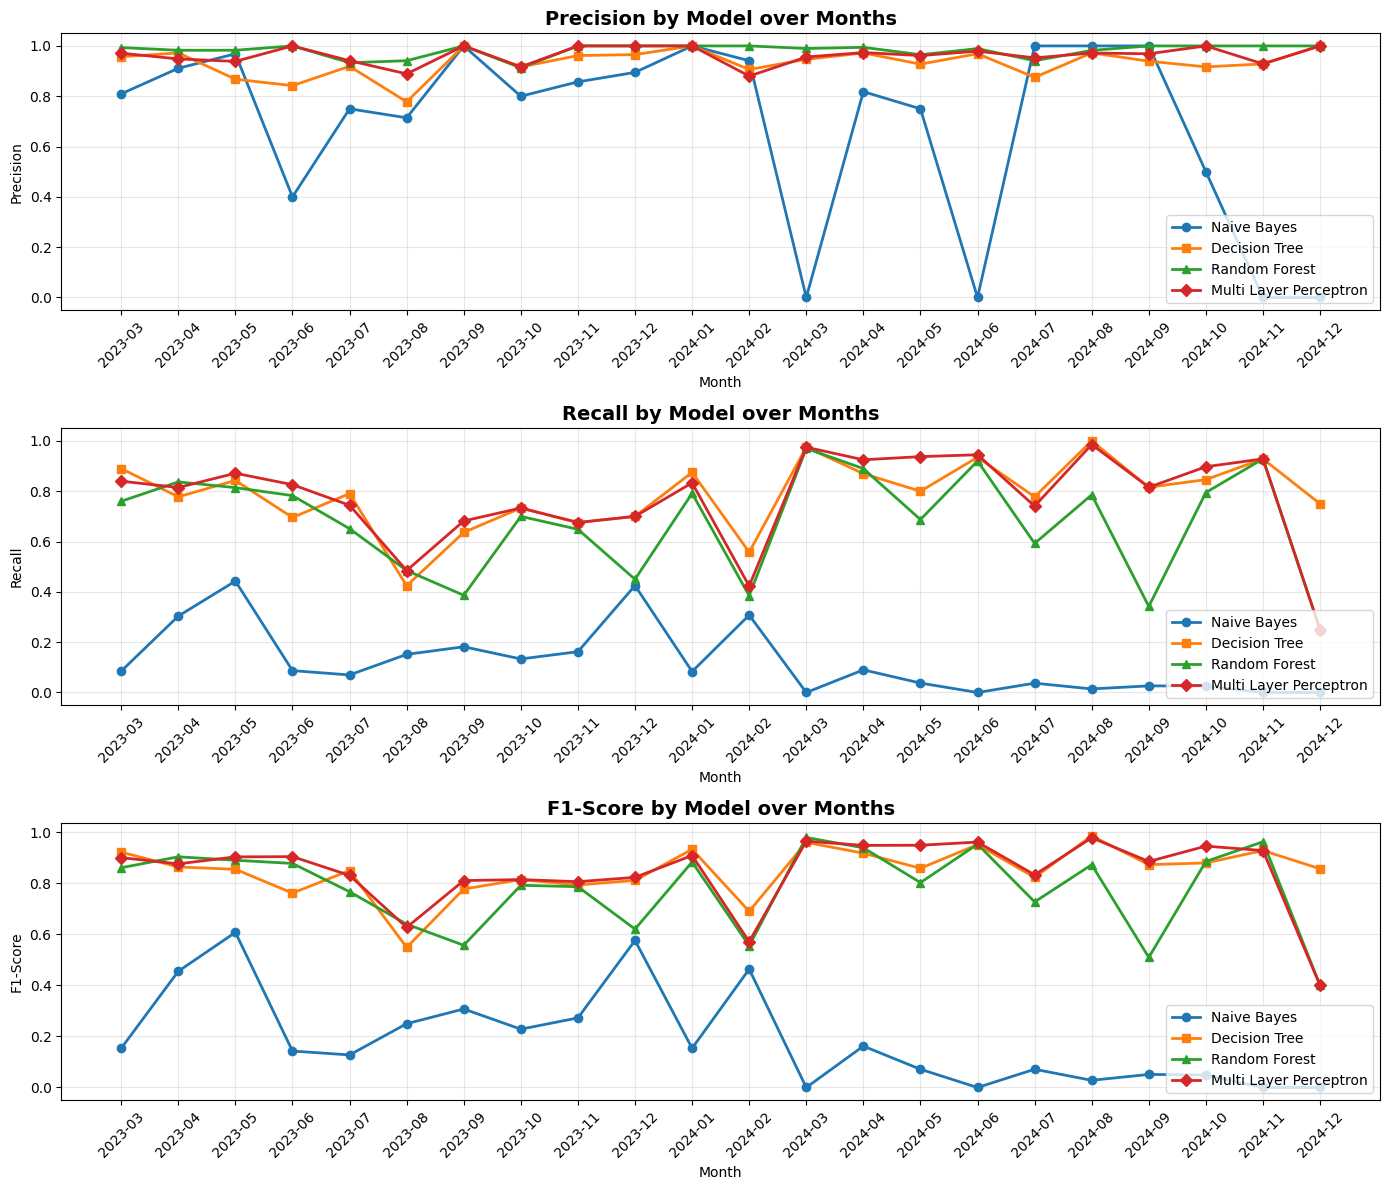

In [3]:
# 读取结果CSV
results_df = pd.read_csv("/Data2/hxq/MalGuard/model_training/malicious_monthly_results.csv")

# 获取所有模型名称
model_names = results_df['Model'].unique()
months = results_df['Month'].unique()

# 创建3个子图
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']

# 图1: Precision
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[0].plot(model_data['Month'], model_data['Precision'],
                 marker=markers[idx], color=colors[idx],
                 linewidth=2, markersize=6, label=model_name)
axes[0].set_title('Precision by Model over Months', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Precision')
axes[0].legend(loc='lower right')
axes[0].set_xticks(range(0, len(months)))
axes[0].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[0].grid(True, alpha=0.3)

# 图2: Recall
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[1].plot(model_data['Month'], model_data['Recall'],
                 marker=markers[idx], color=colors[idx],
                 linewidth=2, markersize=6, label=model_name)
axes[1].set_title('Recall by Model over Months', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Recall')
axes[1].legend(loc='lower right')
axes[1].set_xticks(range(0, len(months)))
axes[1].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[1].grid(True, alpha=0.3)

# 图3: F1-Score
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[2].plot(model_data['Month'], model_data['F1'],
                 marker=markers[idx], color=colors[idx],
                 linewidth=2, markersize=6, label=model_name)
axes[2].set_title('F1-Score by Model over Months', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('F1-Score')
axes[2].legend(loc='lower right')
axes[2].set_xticks(range(0, len(months)))
axes[2].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 计算每个模型的平均指标（表格形式）
mean_stats = results_df.groupby('Model')[['Precision', 'Recall', 'F1']].mean().round(4)
mean_stats.columns = ['Precision', 'Recall', 'F1']
mean_stats = mean_stats.reset_index()  # 把 Model 从索引变成列
mean_stats 

,Model,Precision,Recall,F1
0,Decision Tree,0.9333,0.7863,0.8483
1,Multi Layer Perceptron,0.9626,0.7741,0.8445
2,Naive Bayes,0.6870,0.1211,0.1897
3,Random Forest,0.9822,0.6751,0.7805
